# Homework 04: Neural Networks
**Submission Deadline: July 3, 2026, Friday, 9:30**

---

> **Machine Learning - Foundations and Algorithms** in Summer Semester 2026
>
> - Prof. Gerhard Neumann
> - Instructors for this exercise: Florian Seligmann (florian.seligmann@kit.edu) and Emiliyan Gospodinov (emiliyan.gospodinov@kit.edu)
>
> For general questions about the exercises, please post in the Ilias forum so we can answer them once for all students. Only use email for individual questions whose answers are not relevant to all students.

---


## Homework Info

This homework develops neural-network training from explicit matrix and vector gradients to a practical PyTorch implementation. You will backpropagate through a branched computation graph, implement and optimize a multilayer binary classifier in NumPy, and construct and train a convolutional MNIST classifier with PyTorch.

The homework contains coding tasks, multiple-choice questions, and an optional symbolic derivation. **Only coding and multiple-choice tasks are graded.** Tasks marked with "(Not Graded)" are included to strengthen your understanding, prepare you for the exam, and support discussion in the exercise session.


## Group Submission

- Exercise sheets may be submitted in **groups of up to 3 students**.
- **Every group member must upload the edited notebook to Ilias.** It is not sufficient for only one member to submit. If you forget to upload but at least one other group member submitted the group solution, you receive two thirds of the points the first time this happens and zero points if it happens again.
- **The submission deadline is strict.** Late submissions receive zero points, and submissions by email are not accepted.
- You may join a new group if your previous group dissolves. Each group must submit its own work; duplicate submissions across groups will be checked.
- You can use the team-building forum on Ilias to find group members.

Enter the u-identifiers of your group members in the next cell. Leave unused fields empty.


U-identifiers of group members:

Member 1: uiwkc

Member 2: urelg

Member 3:


## Auto-grading

We use an auto-grading system that checks graded answers with visible and hidden tests. Hidden tests determine the final points for coding and multiple-choice tasks.

To ensure auto-grading works correctly:

- Keep the filename `ex_04_neural_networks.ipynb`.
- Upload only the edited notebook to Ilias as a single raw `.ipynb` file. Do not upload a zip archive or any data files.
- Before submission, restart the kernel and run the notebook from beginning to end. It must complete without errors.
- Enter solutions only in the designated answer and code cells.
- Do not delete, add, reorder, or rename provided cells, functions, parameters, return values, or answer variables.
- Visible asserts help identify common mistakes. Passing them is necessary but not sufficient because additional hidden tests are used for grading.

**If you fail to comply with these rules, your submission may not be graded and you may receive no points for this exercise.**


In [2]:
##### DO NOT CHANGE #####
import numpy as np
from typing import Tuple

##### DO NOT CHANGE #####

## 1) Matrix and Vector Gradients in a Computation Graph (7 Points)

In this exercise, we study a small computation graph for a single sample. It resembles a neural-network layer but also contains a linear skip connection from the input to the output:

```text

x ---------> z = W1 x + b1 ---------> h = tanh(z) ----> u = W2 h 
|                                                       |
+-------------------------> v = S x --------------------+ --> y_hat = u + v + b2 --> L
```

The forward computation is

$$
\boldsymbol{z} = W_1\boldsymbol{x} + \boldsymbol{b}_1,
\qquad
\boldsymbol{h} = \tanh(\boldsymbol{z}),
$$

$$
\boldsymbol{u} = W_2\boldsymbol{h},
\qquad
\boldsymbol{v} = S\boldsymbol{x},
$$

$$
\hat{\boldsymbol{y}}
= \boldsymbol{u} + \boldsymbol{v} + \boldsymbol{b}_2,
\qquad
L = \frac{1}{2}\left\lVert\hat{\boldsymbol{y}}-\boldsymbol{t}\right\rVert_2^2.
$$

We use column-vector notation in the equations. In NumPy, vectors are represented by one-dimensional arrays. For the concrete example below,

$$
\boldsymbol{x},\boldsymbol{t}\in\mathbb{R}^2,
\quad W_1\in\mathbb{R}^{3\times2},
\quad W_2\in\mathbb{R}^{2\times3},
\quad S\in\mathbb{R}^{2\times2}.
$$


### 1.1) Derive the Backward Pass (Not Graded)

Before inserting numerical values, derive the backward pass symbolically. We use the bar notation from the lecture. For any vector node $\boldsymbol{a}$ and matrix node $A$,

$$
\overline{\boldsymbol{a}}
\equiv \frac{\partial L}{\partial \boldsymbol{a}},
\qquad
\overline{A}
\equiv \frac{\partial L}{\partial A}.
$$

Thus, a barred quantity is the gradient of the scalar loss with respect to that node and has the same shape as the corresponding unbarred quantity. The backward pass starts at the loss with

$$
\overline{L}
= \frac{\partial L}{\partial L}
= 1.
$$

Write the adjoints in reverse topological order for

$$
\overline{\hat{\boldsymbol{y}}},\quad
\overline{\boldsymbol{u}},\quad
\overline{\boldsymbol{v}},\quad
\overline{\boldsymbol{b}}_2,\quad
\overline{W}_2,\quad
\overline{\boldsymbol{h}},\quad
\overline{S},\quad
\overline{\boldsymbol{z}},\quad
\overline{W}_1,\quad
\overline{\boldsymbol{b}}_1,\quad
\overline{\boldsymbol{x}}.
$$

Annotate the shape of every adjoint. Pay particular attention to $\overline{\boldsymbol{x}}$, since the input influences the loss through both $\boldsymbol{z}$ and $\boldsymbol{v}$.



### 1.2) Forward Pass (2 Points)

Implement the forward computation in `residual_forward`. Return the scalar loss and all intermediate values needed to inspect the computation.


In [2]:
def residual_forward(
    x: np.ndarray,
    target: np.ndarray,
    W1: np.ndarray,
    b1: np.ndarray,
    W2: np.ndarray,
    S: np.ndarray,
    b2: np.ndarray,
) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute the forward pass for one sample.

    :param x: input vector, shape [input_dim]
    :param target: target vector, shape [output_dim]
    :param W1: hidden-layer weights, shape [hidden_dim, input_dim]
    :param b1: hidden-layer bias, shape [hidden_dim]
    :param W2: output weights, shape [output_dim, hidden_dim]
    :param S: skip-connection weights, shape [output_dim, input_dim]
    :param b2: output bias, shape [output_dim]
    :return: loss, z, h, main node u, skip node v, and prediction
    """
    z = None
    h = None
    u = None
    v = None
    prediction = None
    loss = None

    # YOUR CODE HERE
    z = W1 @ x + b1
    h = np.tanh(z)
    u = W2 @ h
    v = S @ x
    prediction = u + v + b2
    loss = 0.5 * np.sum((prediction - target) ** 2)

    return float(loss), z, h, u, v, prediction


In [3]:
##### DO NOT CHANGE #####
# Concrete values for the forward and backward passes.
x_graph = np.array([1.0, -2.0])
target_graph = np.array([0.5, -1.0])

W1_graph = np.array([
    [1.0, 0.50],
    [0.0, -0.25],
    [-0.5, 0.50],
])
b1_graph = np.array([0.0, 0.0, 1.0])

W2_graph = np.array([
    [0.4, -0.2, 0.3],
    [-0.5, 0.6, -0.1],
])
S_graph = np.array([
    [0.20, -0.10],
    [0.05, 0.30],
])
b2_graph = np.array([0.1, -0.2])

loss_graph, z_graph, h_graph, u_graph, v_graph, prediction_graph = residual_forward(
    x_graph,
    target_graph,
    W1_graph,
    b1_graph,
    W2_graph,
    S_graph,
    b2_graph,
)

print("z:", z_graph)
print("h:", h_graph)
print("u:", u_graph)
print("v:", v_graph)
print("prediction:", prediction_graph)
print("loss:", loss_graph)


##### DO NOT CHANGE #####

z: [ 0.   0.5 -0.5]
h: [ 0.          0.46211716 -0.46211716]
u: [-0.23105858  0.32348201]
v: [ 0.4  -0.55]
prediction: [ 0.26894142 -0.42651799]
loss: 0.19113484132310857


In [4]:
##### DO NOT CHANGE #####
# ID: test_task_1_2 - possible points: 2

# Useful asserts
assert np.isscalar(loss_graph)
assert z_graph.shape == b1_graph.shape
assert h_graph.shape == b1_graph.shape
assert u_graph.shape == target_graph.shape
assert v_graph.shape == target_graph.shape
assert prediction_graph.shape == target_graph.shape
assert np.isfinite(loss_graph) and loss_graph >= 0.0
assert all(np.all(np.isfinite(value)) for value in (z_graph, h_graph, u_graph, v_graph, prediction_graph))



##### DO NOT CHANGE #####

### 1.3) Backward Pass (4 Points)

Implement the backward pass in `residual_backward`. Return gradients with respect to the input and every trainable parameter. Use `np.outer` for the weight gradients. Be careful when computing the gradient with respect to the input  $\boldsymbol{x}$.

In [5]:
def residual_backward(
    x: np.ndarray,
    target: np.ndarray,
    W1: np.ndarray,
    b1: np.ndarray,
    W2: np.ndarray,
    S: np.ndarray,
    b2: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Compute gradients for one sample using backpropagation.

    :return: gradients for x, W1, b1, W2, S, and b2, in that order
    """
    forward_values = None
    h = None
    prediction = None
    grad_prediction = None
    grad_u = None
    grad_v = None
    grad_h = None
    grad_z = None
    grad_x = None
    grad_W1 = None
    grad_b1 = None
    grad_W2 = None
    grad_S = None
    grad_b2 = None

    # YOUR CODE HERE
    forward_values = residual_forward(x, target, W1, b1, W2, S, b2)
    loss, z, h, u, v, prediction = forward_values
    grad_prediction = prediction - target
    grad_u = grad_prediction
    grad_v = grad_prediction
    grad_h = W2.T @ grad_u
    grad_z = grad_h * (1 - h ** 2)
    grad_W1 = np.outer(grad_z, x)
    grad_b1 = grad_z
    grad_W2 = np.outer(grad_u, h)
    grad_S = np.outer(grad_v, x)
    grad_x_from_hidden = W1.T @ grad_z
    grad_x_from_skip = S.T @ grad_v
    grad_x = grad_x_from_hidden + grad_x_from_skip
    grad_b2 = grad_prediction

    return grad_x, grad_W1, grad_b1, grad_W2, grad_S, grad_b2


In [6]:
##### DO NOT CHANGE #####
grad_x_graph, grad_W1_graph, grad_b1_graph, grad_W2_graph, grad_S_graph, grad_b2_graph = residual_backward(
    x_graph,
    target_graph,
    W1_graph,
    b1_graph,
    W2_graph,
    S_graph,
    b2_graph,
)

print("gradient w.r.t. x:")
print(grad_x_graph)
print("gradient w.r.t. W1:")
print(grad_W1_graph)
print("gradient w.r.t. b1:")
print(grad_b1_graph)
print("gradient w.r.t. W2:")
print(grad_W2_graph)
print("gradient w.r.t. S:")
print(grad_S_graph)
print("gradient w.r.t. b2:")
print(grad_b2_graph)


##### DO NOT CHANGE #####

gradient w.r.t. x:
[-0.34689405 -0.12097758]
gradient w.r.t. W1:
[[-0.37916444  0.75832887]
 [ 0.30695128 -0.61390255]
 [-0.09961601  0.19923202]]
gradient w.r.t. b1:
[-0.37916444  0.30695128 -0.09961601]
gradient w.r.t. W2:
[[-0.         -0.10677613  0.10677613]
 [ 0.          0.26501588 -0.26501588]]
gradient w.r.t. S:
[[-0.23105858  0.46211716]
 [ 0.57348201 -1.14696402]]
gradient w.r.t. b2:
[-0.23105858  0.57348201]


In [7]:
##### DO NOT CHANGE #####
# ID: test_task_1_3 - possible points: 4

# Useful asserts
assert grad_x_graph.shape == x_graph.shape
assert grad_W1_graph.shape == W1_graph.shape
assert grad_b1_graph.shape == b1_graph.shape
assert grad_W2_graph.shape == W2_graph.shape
assert grad_S_graph.shape == S_graph.shape
assert grad_b2_graph.shape == b2_graph.shape
assert np.all(np.isfinite(grad_x_graph))
assert np.all(np.isfinite(grad_W1_graph))
assert np.all(np.isfinite(grad_b1_graph))
assert np.all(np.isfinite(grad_W2_graph))
assert np.all(np.isfinite(grad_S_graph))
assert np.all(np.isfinite(grad_b2_graph))



##### DO NOT CHANGE #####

### 1.4) Gradient Flow Through the Network (1 Point)

Assume that $W_2$ is initialized to the zero matrix, while $\boldsymbol{h}\neq\boldsymbol{0}$ and the prediction error $\overline{\hat{\boldsymbol{y}}}\neq\boldsymbol{0}$. What happens during the first backward pass?

- a) $W_2$ receives a non-zero gradient, but $W_1$ and $\boldsymbol{b}_1$ receive zero gradients.
- b) Neither $W_2$ nor $W_1$ receives a gradient because the main-path output is zero.
- c) $W_1$ receives a non-zero gradient, but $W_2$ receives a zero gradient.
- d) All parameter gradients are necessarily zero.

In the next cell, write your answer as a Python string containing one lowercase letter in `answer_1_4`.


In [8]:
answer_1_4 = "a"


In [9]:
##### DO NOT CHANGE #####
# ID: test_task_1_4 - possible points: 1

assert answer_1_4 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

## 2) Neural Network Classifier from Scratch (14 Points)

In this exercise, you will implement a small neural network from scratch using only NumPy. This is mainly a learning exercise: in practice, automatic-differentiation libraries perform these operations for us.

The network consists of an arbitrary number of hidden layers with ReLU activations and a sigmoid output layer for binary classification. We train it by minimizing binary cross-entropy, the negative Bernoulli log-likelihood.

For consistency with the lecture, a layer stores $W_\ell\in\mathbb{R}^{d_\ell\times d_{\ell-1}}$ and $\boldsymbol{b}_\ell\in\mathbb{R}^{d_\ell}$. Samples are rows of a batch matrix, so the corresponding NumPy computation is `H @ W.T + b`.

In [4]:
##### DO NOT CHANGE #####
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

# Load the two-moons training and test data.
two_moons_train_data = dict(np.load("two_moons.npz", allow_pickle=True)) 
two_moons_test_data = dict(np.load("two_moons_test.npz", allow_pickle=True))
# Represent each binary label as a one-dimensional output vector.
two_moons_train_samples = two_moons_train_data["samples"]
two_moons_train_labels = two_moons_train_data["labels"][:, None]
two_moons_test_samples = two_moons_test_data["samples"]
two_moons_test_labels = two_moons_test_data["labels"][:, None]

##### DO NOT CHANGE #####

### 2.1) Auxiliary Functions (3 Points)
Implement the ReLU and sigmoid activation functions, binary cross-entropy, and their derivatives. We define the ReLU derivative at zero to be zero.

For $N$ predictions, binary cross-entropy is

$$
L_{\mathrm{BCE}}=-\frac{1}{N}\sum_{i=1}^N\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right],
$$

where $y_i$ is the target and $p_i$ is the predicted probability. Clip probabilities inside the loss and its derivative to avoid evaluating $\log(0)$ or dividing by zero.


In [11]:
def relu(x: np.ndarray) -> np.ndarray:
    """Apply ReLU element-wise."""
    result = None
    # YOUR CODE HERE
    result = np.maximum(0, x)
    return result


def d_relu(x: np.ndarray) -> np.ndarray:
    """Return the element-wise ReLU derivative, using zero at x = 0."""
    result = None
    # YOUR CODE HERE
    result = (x > 0).astype(float)
    return result


def sigmoid(x: np.ndarray) -> np.ndarray:
    """Apply the sigmoid function element-wise."""
    clipped_x = None
    result = None
    # YOUR CODE HERE
    clipped_x = np.clip(x, -500, 500)
    result = 1 / (1 + np.exp(-clipped_x))
    return result


def d_sigmoid(x: np.ndarray) -> np.ndarray:
    """Return the element-wise sigmoid derivative."""
    sigmoid_x = None
    result = None
    # YOUR CODE HERE
    sigmoid_x = sigmoid(x)
    result = sigmoid_x * (1 - sigmoid_x)
    return result


def binary_cross_entropy(predictions: np.ndarray, labels: np.ndarray) -> float:
    """Return mean binary cross-entropy over all prediction entries."""
    clipped_predictions = None
    elementwise_loss = None
    loss = None
    # YOUR CODE HERE
    eps = 1e-15
    clipped_predictions = np.clip(predictions, eps, 1 - eps)
    elementwise_loss = -(
        labels * np.log(clipped_predictions)
        + (1 - labels) * np.log(1 - clipped_predictions)
    )
    loss = np.mean(elementwise_loss)
    return float(loss)


def d_binary_cross_entropy(predictions: np.ndarray, labels: np.ndarray) -> np.ndarray:
    """Return the gradient of mean BCE with respect to predictions."""
    clipped_predictions = None
    gradient = None
    # YOUR CODE HERE
    eps = 1e-15
    clipped_predictions = np.clip(predictions, eps, 1 - eps)
    gradient = (clipped_predictions - labels) / (
        clipped_predictions * (1 - clipped_predictions)
    )
    gradient = gradient / predictions.size
    return gradient

In [12]:
##### DO NOT CHANGE #####
# ID: test_task_2_1 - possible points: 3

# Useful asserts
activation_test = np.array([-2.0, 0.0, 1.5])
relu_test = relu(activation_test)
d_relu_test = d_relu(activation_test)
sigmoid_test = sigmoid(activation_test)
d_sigmoid_test = d_sigmoid(activation_test)
assert relu_test.shape == activation_test.shape
assert d_relu_test.shape == activation_test.shape
assert sigmoid_test.shape == activation_test.shape
assert d_sigmoid_test.shape == activation_test.shape
assert np.all(np.isfinite(relu_test)) and np.all(relu_test >= 0.0)
assert np.all(np.isin(d_relu_test, (0.0, 1.0)))
assert np.all(np.isfinite(sigmoid_test)) and np.all((0.0 < sigmoid_test) & (sigmoid_test < 1.0))
assert np.all(np.isfinite(d_sigmoid_test)) and np.all((0.0 <= d_sigmoid_test) & (d_sigmoid_test <= 0.25))

predictions_test = np.array([[0.8], [0.25]])
labels_test = np.array([[1.0], [0.0]])
loss_test = binary_cross_entropy(predictions_test, labels_test)
loss_gradient_test = d_binary_cross_entropy(predictions_test, labels_test)
assert np.isscalar(loss_test) and np.isfinite(loss_test) and loss_test >= 0.0
assert loss_gradient_test.shape == predictions_test.shape
assert np.all(np.isfinite(loss_gradient_test))



##### DO NOT CHANGE #####

### 2.2) Network Initialization (2 Points)

Represent the network by one weight matrix and one bias vector per layer. For a layer with input width $d_{\mathrm{in}}$ and output width $d_{\mathrm{out}}$, use shapes $(d_{\mathrm{out}},d_{\mathrm{in}})$ and $(d_{\mathrm{out}},)$.

Initialize hidden ReLU layers with standard deviation $\sqrt{2/d_{\mathrm{in}}}$ (He initialization), the sigmoid output layer with $\sqrt{1/d_{\mathrm{in}}}$ (Xavier initialization), and all biases with zero.


In [14]:
def init_weights(
    neurons_per_hidden_layer: List[int],
    input_dim: int,
    output_dim: int,
    seed: int = 0,
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """Initialize lecture-oriented weights and one-dimensional biases."""
    layer_dims = None
    rng = None
    weights = []
    biases = []
    layer_index = None
    fan_in = None
    fan_out = None
    scale = None
    weight = None
    bias = None

    # YOUR CODE HERE
    layer_dims = [input_dim] + neurons_per_hidden_layer + [output_dim]
    rng = np.random.default_rng(seed)

    for layer_index in range(len(layer_dims) - 1):
        fan_in = layer_dims[layer_index]
        fan_out = layer_dims[layer_index + 1]

        if layer_index < len(layer_dims) - 2:
            scale = np.sqrt(2 / fan_in)
        else:
            scale = np.sqrt(1 / fan_in)

        weight = rng.normal(loc=0.0, scale=scale, size=(fan_out, fan_in))
        bias = np.zeros(fan_out)

        weights.append(weight)
        biases.append(bias)

    return weights, biases

In [15]:
##### DO NOT CHANGE #####
# ID: test_task_2_2 - possible points: 2

# Useful asserts
weights_init_test, biases_init_test = init_weights([4, 3], 2, 1, seed=5)
assert [weight.shape for weight in weights_init_test] == [(4, 2), (3, 4), (1, 3)]
assert [bias.shape for bias in biases_init_test] == [(4,), (3,), (1,)]
assert all(np.allclose(bias, 0.0) for bias in biases_init_test)
weights_repeat_test, biases_repeat_test = init_weights([4, 3], 2, 1, seed=5)
assert all(np.array_equal(first, second) for first, second in zip(weights_init_test, weights_repeat_test))
assert all(np.array_equal(first, second) for first, second in zip(biases_init_test, biases_repeat_test))



##### DO NOT CHANGE #####

### 2.3) Forward Pass (3 Points)

Propagate a batch $H_0=X$ through the network. For every layer, compute

$$
Z_\ell=H_{\ell-1}W_\ell^T+\boldsymbol{b}_\ell.
$$

Apply ReLU after hidden layers and sigmoid after the output layer. Store the layer inputs in `hs` and all pre-activations in `zs`, since the backward pass reuses them. Thus, `hs` and `zs` both have one entry per weight matrix.


In [16]:
def forward_pass(
    x: np.ndarray,
    weights: List[np.ndarray],
    biases: List[np.ndarray],
) -> Tuple[np.ndarray, List[np.ndarray], List[np.ndarray]]:
    """Propagate a row-oriented batch through the network."""
    hs = []
    zs = []
    h = None
    z = None
    layer_index = None
    predictions = None

    # YOUR CODE HERE
    h = x

    for layer_index in range(len(weights)):
        hs.append(h)

        z = h @ weights[layer_index].T + biases[layer_index]
        zs.append(z)

        if layer_index < len(weights) - 1:
            h = relu(z)
        else:
            h = sigmoid(z)

    predictions = h

    return predictions, hs, zs

In [17]:
##### DO NOT CHANGE #####
# ID: test_task_2_3 - possible points: 3

# Useful asserts
x_forward_test = np.array([[1.0, -2.0], [0.5, 1.0]])
weights_forward_test = [
    np.array([[1.0, 0.5], [-0.5, 1.0]]),
    np.array([[0.4, -0.3]]),
]
biases_forward_test = [np.array([0.1, -0.2]), np.array([0.2])]
predictions_forward_test, hs_forward_test, zs_forward_test = forward_pass(
    x_forward_test, weights_forward_test, biases_forward_test
)
assert predictions_forward_test.shape == (2, 1)
assert len(hs_forward_test) == len(zs_forward_test) == len(weights_forward_test)
assert [value.shape for value in hs_forward_test] == [(2, 2), (2, 2)]
assert [value.shape for value in zs_forward_test] == [(2, 2), (2, 1)]
assert np.all(np.isfinite(predictions_forward_test))
assert np.all((0.0 <= predictions_forward_test) & (predictions_forward_test <= 1.0))
assert all(np.all(np.isfinite(value)) for value in hs_forward_test + zs_forward_test)



##### DO NOT CHANGE #####

### 2.4) Backward Pass (4 Points)

Use backpropagation to compute one gradient for every weight matrix and bias vector. The initial upstream gradient is the derivative of the mean binary cross-entropy with respect to the predictions.

For a row-oriented batch, the parameter gradients of one layer are

$$
\overline{W}_\ell=\Delta_\ell^T H_{\ell-1},
\qquad
\overline{\boldsymbol{b}}_\ell=\sum_{i=1}^N\Delta_{\ell,i},
$$

where $\Delta_\ell$ contains one pre-activation error signal per sample. Do not average again in `backward_pass`: the factor $1/N$ is already included in `loss_grad`.


In [18]:
def backward_pass(
    loss_grad: np.ndarray,
    hs: List[np.ndarray],
    zs: List[np.ndarray],
    weights: List[np.ndarray],
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """Backpropagate through all layers and return parameter gradients."""
    d_weights = [None] * len(weights)
    d_biases = [None] * len(weights)
    delta = None
    layer_index = None

    # YOUR CODE HERE
    for layer_index in reversed(range(len(weights))):
        if layer_index == len(weights) - 1:
            # Output layer: sigmoid activation
            delta = loss_grad * d_sigmoid(zs[layer_index])
        else:
            # Hidden layers: ReLU activation
            delta = delta @ weights[layer_index + 1]
            delta = delta * d_relu(zs[layer_index])

        d_weights[layer_index] = delta.T @ hs[layer_index]
        d_biases[layer_index] = np.sum(delta, axis=0)

    return d_weights, d_biases

In [19]:
##### DO NOT CHANGE #####
# ID: test_task_2_4 - possible points: 4

# Useful asserts
labels_backward_test = np.array([[1.0], [0.0]])
loss_grad_backward_test = d_binary_cross_entropy(
    predictions_forward_test, labels_backward_test
)
d_weights_test, d_biases_test = backward_pass(
    loss_grad_backward_test, hs_forward_test, zs_forward_test, weights_forward_test
)
assert len(d_weights_test) == len(weights_forward_test)
assert len(d_biases_test) == len(biases_forward_test)
assert all(gradient.shape == weight.shape for gradient, weight in zip(d_weights_test, weights_forward_test))
assert all(gradient.shape == bias.shape for gradient, bias in zip(d_biases_test, biases_forward_test))
assert all(np.all(np.isfinite(gradient)) for gradient in d_weights_test + d_biases_test)



##### DO NOT CHANGE #####

### 2.5) Optimization (2 Points)

Implement one parameter-update step with momentum. For every gradient $\boldsymbol{g}_k$, update its running average according to
$$\boldsymbol{m}_{k+1} = \gamma \boldsymbol{m}_k + (1 - \gamma) \boldsymbol{g}_k$$
where $\gamma$ is the momentum factor. Then update each parameter with $\boldsymbol{\theta}_{k+1}=\boldsymbol{\theta}_k-\eta\boldsymbol{m}_{k+1}$. The complete mini-batch training loop is provided below.

In [23]:
def momentum_update(
    weights: List[np.ndarray],
    biases: List[np.ndarray],
    weight_grads: List[np.ndarray],
    bias_grads: List[np.ndarray],
    momentum_weights: List[np.ndarray],
    momentum_biases: List[np.ndarray],
    learning_rate: float,
    momentum_factor: float,
) -> Tuple[List[np.ndarray], List[np.ndarray], List[np.ndarray], List[np.ndarray]]:
    """Return updated parameters and momentum buffers without modifying the inputs."""
    updated_weights = []
    updated_biases = []
    updated_momentum_weights = []
    updated_momentum_biases = []
    layer_index = None
    next_momentum_weight = None
    next_momentum_bias = None

    # YOUR CODE HERE
    for layer_index in range(len(weights)):
        next_momentum_weight = (
            momentum_factor * momentum_weights[layer_index]
            + (1 - momentum_factor) * weight_grads[layer_index]
        )

        next_momentum_bias = (
            momentum_factor * momentum_biases[layer_index]
            + (1 - momentum_factor) * bias_grads[layer_index]
        )

        updated_weight = weights[layer_index] - learning_rate * next_momentum_weight
        updated_bias = biases[layer_index] - learning_rate * next_momentum_bias

        updated_weights.append(updated_weight)
        updated_biases.append(updated_bias)
        updated_momentum_weights.append(next_momentum_weight)
        updated_momentum_biases.append(next_momentum_bias)

    return (
        updated_weights, updated_biases,
        updated_momentum_weights, updated_momentum_biases,
    )

def train_neural_net(
    train_samples: np.ndarray,
    train_labels: np.ndarray,
    test_samples: np.ndarray,
    test_labels: np.ndarray,
    layers: List[int],
    learning_rate: float,
    momentum_factor: float,
    num_iterations: int,
    batch_size: int,
    seed: int = 0,
) -> Tuple[List[np.ndarray], List[np.ndarray], np.ndarray, np.ndarray]:
    """Train the network and record train/test loss after every update."""
    assert 1 <= batch_size <= train_samples.shape[0]
    assert 0.0 <= momentum_factor < 1.0

    weights, biases = init_weights(
        layers, train_samples.shape[1], train_labels.shape[1], seed=seed
    )
    momentum_weights = [np.zeros_like(weight) for weight in weights]
    momentum_biases = [np.zeros_like(bias) for bias in biases]
    train_losses = []
    test_losses = []
    rng = np.random.default_rng(seed + 1)

    for _ in range(num_iterations):
        shuffled_indices = rng.permutation(train_samples.shape[0])
        for start in range(0, train_samples.shape[0], batch_size):
            batch_indices = shuffled_indices[start:start + batch_size]
            sample_batch = train_samples[batch_indices]
            label_batch = train_labels[batch_indices]

            prediction, hs, zs = forward_pass(sample_batch, weights, biases)
            train_losses.append(binary_cross_entropy(prediction, label_batch))
            loss_grad = d_binary_cross_entropy(prediction, label_batch)
            weight_grads, bias_grads = backward_pass(loss_grad, hs, zs, weights)
            (
                weights, biases, momentum_weights, momentum_biases
            ) = momentum_update(
                weights, biases, weight_grads, bias_grads,
                momentum_weights, momentum_biases,
                learning_rate, momentum_factor,
            )

            test_prediction = forward_pass(test_samples, weights, biases)[0]
            test_losses.append(binary_cross_entropy(test_prediction, test_labels))

    return weights, biases, np.asarray(train_losses), np.asarray(test_losses)

In [24]:
##### DO NOT CHANGE #####
# ID: test_task_2_5 - possible points: 2

# Useful asserts
weights_update_test = [np.array([[1.0, -0.5], [0.2, 0.7]])]
biases_update_test = [np.array([0.1, -0.2])]
weight_grads_test = [np.array([[0.4, -0.2], [0.6, 0.1]])]
bias_grads_test = [np.array([0.3, -0.5])]
momentum_weights_test = [np.zeros((2, 2))]
momentum_biases_test = [np.zeros(2)]
weights_before_test = [value.copy() for value in weights_update_test]
biases_before_test = [value.copy() for value in biases_update_test]
momentum_weights_before_test = [value.copy() for value in momentum_weights_test]
momentum_biases_before_test = [value.copy() for value in momentum_biases_test]
updated_test = momentum_update(
    weights_update_test, biases_update_test, weight_grads_test, bias_grads_test,
    momentum_weights_test, momentum_biases_test,
    learning_rate=0.1, momentum_factor=0.5,
)
assert len(updated_test) == 4
assert all(len(values) == len(weights_update_test) for values in updated_test)
assert updated_test[0][0].shape == weights_update_test[0].shape
assert updated_test[1][0].shape == biases_update_test[0].shape
assert updated_test[2][0].shape == momentum_weights_test[0].shape
assert updated_test[3][0].shape == momentum_biases_test[0].shape
assert all(np.all(np.isfinite(value)) for values in updated_test for value in values)
assert all(np.array_equal(actual, expected) for actual, expected in zip(weights_update_test, weights_before_test))
assert all(np.array_equal(actual, expected) for actual, expected in zip(biases_update_test, biases_before_test))
assert all(np.array_equal(actual, expected) for actual, expected in zip(momentum_weights_test, momentum_weights_before_test))
assert all(np.array_equal(actual, expected) for actual, expected in zip(momentum_biases_test, momentum_biases_before_test))



##### DO NOT CHANGE #####

### Putting Everything Together (Not Graded)

Train the complete network and visualize its predictions. With the provided seed and hyperparameters, both training and test accuracy should exceed $0.95$.

Train Accuracy: 1.0
Test Accuracy: 0.99


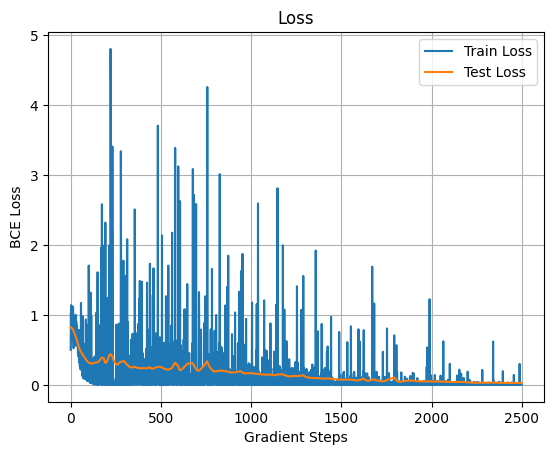

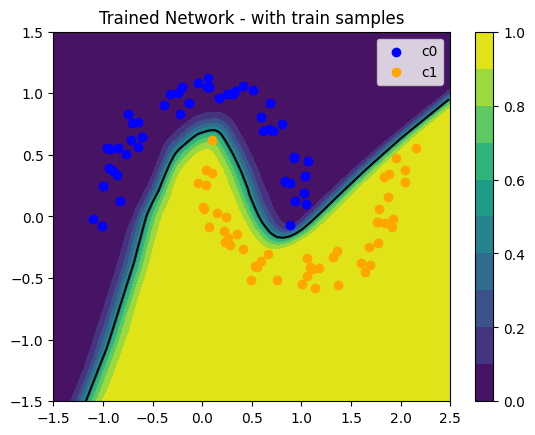

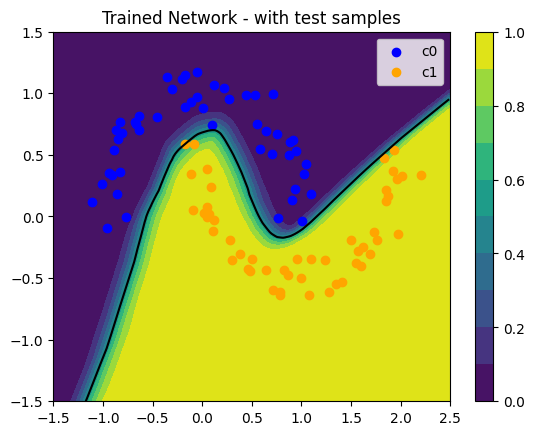

In [25]:
##### DO NOT CHANGE #####
# Train the network.
weights, biases, train_losses, test_losses = train_neural_net(train_samples=two_moons_train_samples,
                                                              train_labels=two_moons_train_labels,
                                                              test_samples=two_moons_test_samples,
                                                              test_labels=two_moons_test_labels,
                                                              learning_rate=5e-2,
                                                              num_iterations=25,
                                                              momentum_factor=0.99,
                                                              batch_size=1,
                                                              layers=[64, 64],
                                                              seed=42)

# plotting
plt.title("Loss")
plt.plot(train_losses)
plt.plot(test_losses)
plt.xlabel("Gradient Steps")
plt.ylabel("BCE Loss")
plt.grid(True)
plt.legend(["Train Loss", "Test Loss"])


# Evaluate accuracy.
train_predictions = forward_pass(two_moons_train_samples, weights, biases)[0]
test_predictions = forward_pass(two_moons_test_samples, weights, biases)[0]

predicted_train_labels = (train_predictions >= 0.5).astype(float)
train_accuracy = np.mean(predicted_train_labels == two_moons_train_labels)
print("Train Accuracy:", train_accuracy)

predicted_test_labels = (test_predictions >= 0.5).astype(float)
test_accuracy = np.mean(predicted_test_labels == two_moons_test_labels)
print("Test Accuracy:", test_accuracy)
assert train_accuracy > 0.95
assert test_accuracy > 0.95


def plot_decision_boundary(samples, labels):
    plt_range = np.arange(-1.5, 2.5, 0.01)
    plt_grid = np.stack(np.meshgrid(plt_range, plt_range), axis=-1)
    plt_grid_shape = plt_grid.shape[:2]
    pred_grid = np.reshape(forward_pass(plt_grid, weights, biases)[0], plt_grid_shape)
    plt.contour(plt_grid[..., 0], plt_grid[..., 1], pred_grid, levels=[0.5], colors=["black"])
    plt.contourf(plt_grid[..., 0], plt_grid[..., 1], pred_grid, levels=10)
    plt.colorbar()
    s0 = plt.scatter(x=samples[labels[:, 0] == 0, 0], y=samples[labels[:, 0] == 0, 1],
                     label="c=0", c="blue")
    s1 = plt.scatter(x=samples[labels[:, 0] == 1, 0], y=samples[labels[:, 0] == 1, 1],
                     label="c=1", c="orange")
    plt.legend([s0, s1], ["c0", "c1"])
    plt.xlim(-1.5, 2.5)
    plt.ylim(-1.5, 1.5)


plt.figure()
plt.title("Trained Network - with train samples")
plot_decision_boundary(two_moons_train_samples, two_moons_train_labels)

plt.figure()
plt.title("Trained Network - with test samples")
plot_decision_boundary(two_moons_test_samples, two_moons_test_labels)
plt.show()


##### DO NOT CHANGE #####

## 3) MNIST Classifier with PyTorch (6 Points)

In Task 2, you implemented forward and backward propagation manually. Here, you will use PyTorch, which provides neural-network layers, automatic differentiation, and optimizers.

We use MNIST, a ten-class dataset of grayscale handwritten digits. Each image has shape $28\times28$. PyTorch convolutional layers expect batches in `NCHW` layout: batch size, channels, height, and width. Therefore, each input batch has shape `(N, 1, 28, 28)`.

Class labels are stored as integer indices from 0 to 9, as expected by `torch.nn.functional.cross_entropy`.


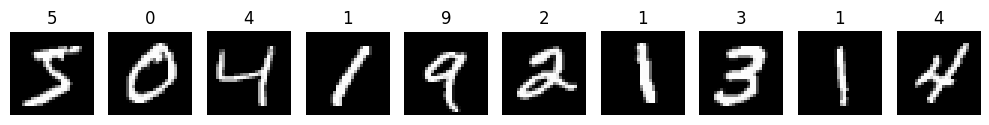

In [5]:
##### DO NOT CHANGE #####
import torch

data_dict = dict(np.load("mnist.npz"))

# Normalize images to [0, 1], add the channel axis, and keep labels as class indices.
train_samples = torch.from_numpy(
    data_dict["train_samples"].astype(np.float32) / 255.0
).unsqueeze(1)
train_labels = torch.from_numpy(data_dict["train_labels"]).long()
test_samples = torch.from_numpy(
    data_dict["test_samples"].astype(np.float32) / 255.0
).unsqueeze(1)
test_labels = torch.from_numpy(data_dict["test_labels"]).long()

assert train_samples.ndim == 4 and train_samples.shape[1:] == (1, 28, 28)
assert train_labels.dtype == torch.int64

# Visualize the first ten training images.
plt.figure(figsize=(10, 1.5))
for image_index in range(10):
    plt.subplot(1, 10, image_index + 1)
    plt.imshow(train_samples[image_index, 0], cmap="gray", interpolation="none")
    plt.title(str(train_labels[image_index].item()))
    plt.axis("off")
plt.tight_layout()


##### DO NOT CHANGE #####

### 3.1) Convolutional Architecture (3 Points)

Implement `get_conv_net` with the following architecture:

1. `Conv2d`: 1 input channel, 8 output channels, kernel size 3, padding 1
2. `ReLU` and `MaxPool2d` with kernel size 2
3. `Conv2d`: 8 input channels, 16 output channels, kernel size 3, padding 1
4. `ReLU` and `MaxPool2d` with kernel size 2
5. `Flatten`
6. `Linear`: $16\cdot7\cdot7$ inputs and 64 outputs, followed by `ReLU`
7. `Linear`: 64 inputs and `num_classes` outputs

The final layer must return unnormalized class scores, called **logits**. Do not add a softmax layer.

Because padding preserves each convolution's spatial size and each pooling layer halves it, the image size changes as $28\rightarrow14\rightarrow7$.

In [6]:
nn = torch.nn

def get_conv_net(num_classes: int = 10) -> nn.Sequential:
    """Construct the convolutional MNIST classifier."""
    layers = []
    model = None

    # YOUR CODE HERE
    layers = [
        nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),

        nn.Flatten(),

        nn.Linear(32 * 7 * 7, 128),
        nn.ReLU(),

        nn.Linear(128, num_classes),
    ]

    model = nn.Sequential(*layers)

    return model

In [7]:
##### DO NOT CHANGE #####
# ID: test_task_3_1 - possible points: 3

# Useful asserts
model_test = get_conv_net(num_classes=10)
logits_test = model_test(torch.zeros(4, 1, 28, 28))
assert isinstance(model_test, nn.Sequential)
assert logits_test.shape == (4, 10)
assert torch.isfinite(logits_test).all()
assert not any(isinstance(layer, nn.Softmax) for layer in model_test)



##### DO NOT CHANGE #####

### 3.2) Logits and Cross-Entropy (1 Point)

Why should the network return logits rather than applying softmax before calling `torch.nn.functional.cross_entropy`?

- a) `cross_entropy` combines log-softmax and negative log-likelihood in a numerically stable operation.
- b) Logits are already normalized class probabilities.
- c) Applying softmax would make automatic differentiation impossible.
- d) Softmax can only be used for binary classification.

In the next cell, write your answer as a Python string containing one lowercase letter in `answer_3_2`.

In [8]:
answer_3_2 = "a"


In [9]:
##### DO NOT CHANGE #####
# ID: test_task_3_2 - possible points: 1

assert answer_3_2 in ("a", "b", "c", "d")



##### DO NOT CHANGE #####

### 3.3) Training Step (2 Points)

Implement an optimization step in `train_step`:

1. Put the model into training mode and clear old gradients.
2. Compute logits and the cross-entropy loss.
3. Run the backward pass and update the parameters.
4. Return the detached loss as a Python `float`.


In [11]:
def train_step(
    model: nn.Module,
    samples: torch.Tensor,
    labels: torch.Tensor,
    optimizer: torch.optim.Optimizer,
) -> float:
    """Perform one optimization step and then return the detached loss."""
    logits = None
    loss = None
    loss_value = None

    # YOUR CODE HERE
    optimizer.zero_grad()

    logits = model(samples)
    loss = torch.nn.functional.cross_entropy(logits, labels)

    loss.backward()
    optimizer.step()

    loss_value = loss.detach().item()

    return loss_value

In [12]:
##### DO NOT CHANGE #####
# ID: test_task_3_3 - possible points: 2

# Useful asserts
torch.manual_seed(4)
step_model_test = nn.Linear(3, 2)
step_optimizer_test = torch.optim.SGD(step_model_test.parameters(), lr=0.1)
step_samples_test = torch.tensor([[0.2, -0.5, 1.0], [1.1, 0.3, -0.7]])
step_labels_test = torch.tensor([1, 0])
parameters_before_test = [parameter.detach().clone() for parameter in step_model_test.parameters()]
step_loss_test = train_step(
    step_model_test, step_samples_test, step_labels_test, step_optimizer_test
)
assert isinstance(step_loss_test, float)
assert np.isfinite(step_loss_test) and step_loss_test >= 0.0
assert step_model_test.training
assert any(not torch.equal(before, after) for before, after in zip(parameters_before_test, step_model_test.parameters()))



##### DO NOT CHANGE #####

### Training the Complete Classifier (Not Graded)

Run the provided loop to train the CNN. The final test accuracy should exceed $0.95$.

Epoch 01: test loss=0.082, test accuracy=0.976
Epoch 02: test loss=0.056, test accuracy=0.982
Epoch 03: test loss=0.038, test accuracy=0.989


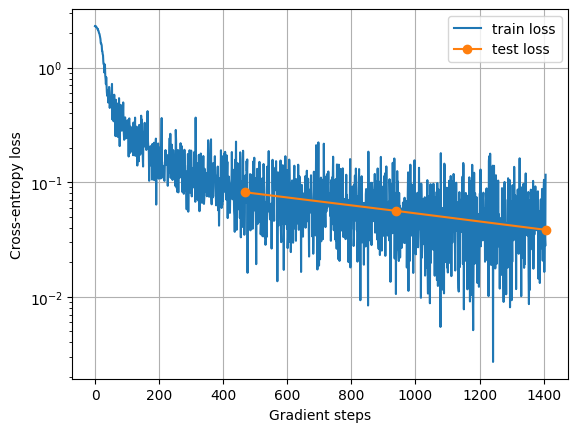

In [13]:
##### DO NOT CHANGE #####
def evaluate_classifier(
    model: nn.Module,
    samples: torch.Tensor,
    labels: torch.Tensor,
    evaluation_batch_size: int = 1024,
) -> Tuple[float, float]:
    """Return mean cross-entropy and classification accuracy."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    with torch.inference_mode():
        for start in range(0, samples.shape[0], evaluation_batch_size):
            sample_batch = samples[start:start + evaluation_batch_size]
            label_batch = labels[start:start + evaluation_batch_size]
            logits = model(sample_batch)
            total_loss += float(
                nn.functional.cross_entropy(logits, label_batch, reduction="sum")
            )
            total_correct += int((logits.argmax(dim=1) == label_batch).sum())
    return total_loss / samples.shape[0], total_correct / samples.shape[0]


torch.manual_seed(0)
num_epochs = 3
batch_size = 128
classifier = get_conv_net(num_classes=10)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
train_set = torch.utils.data.TensorDataset(train_samples, train_labels)
loader_generator = torch.Generator().manual_seed(0)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True, generator=loader_generator
)

train_losses = []
test_losses = []
test_accuracies = []
for epoch in range(num_epochs):
    for sample_batch, label_batch in train_loader:
        train_losses.append(
            train_step(classifier, sample_batch, label_batch, optimizer)
        )

    test_loss, test_accuracy = evaluate_classifier(
        classifier, test_samples, test_labels
    )
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    print(
        f"Epoch {epoch + 1:02d}: "
        f"test loss={test_loss:.3f}, test accuracy={test_accuracy:.3f}"
    )

assert test_accuracies[-1] > 0.95

plt.figure()
plt.semilogy(train_losses, label="train loss")
epoch_steps = np.arange(1, num_epochs + 1) * len(train_loader)
plt.semilogy(epoch_steps, test_losses, marker="o", label="test loss")
plt.xlabel("Gradient steps")
plt.ylabel("Cross-entropy loss")
plt.grid(True)
plt.legend()
plt.show()

##### DO NOT CHANGE #####

### Inspecting Individual Predictions (Not Graded)

Choose test-image indices in the next cell to inspect the classifier's predictions. Softmax is used here only to display a confidence value; the predicted class could equivalently be obtained directly from the largest logit.

In [14]:
# Change these indices to inspect different test images.
image_indices = [0, 7, 12, 25, 42]


Test image     0: true=5, predicted=5, confidence=90.4%
Test image     7: true=3, predicted=3, confidence=100.0%
Test image    12: true=3, predicted=3, confidence=100.0%
Test image    25: true=2, predicted=2, confidence=100.0%
Test image    42: true=7, predicted=7, confidence=96.4%


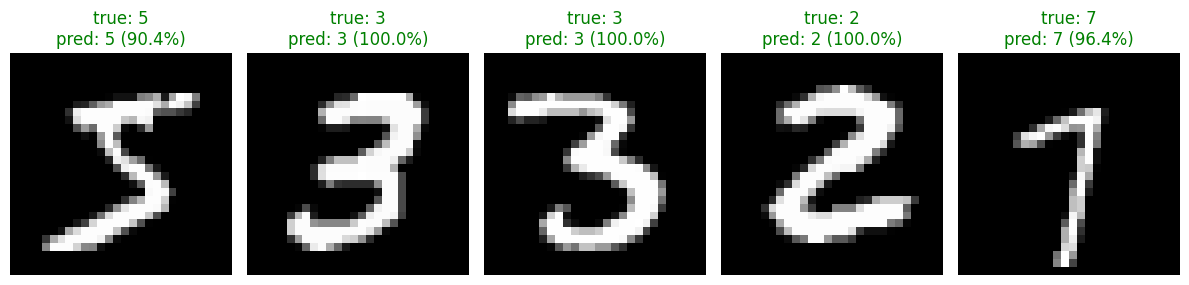

In [15]:
##### DO NOT CHANGE #####

assert image_indices, "Select at least one test image."
assert all(0 <= index < len(test_samples) for index in image_indices)

selected_images = test_samples[image_indices]
selected_labels = test_labels[image_indices]
classifier.eval()
with torch.inference_mode():
    selected_logits = classifier(selected_images)
    selected_probabilities = nn.functional.softmax(selected_logits, dim=1)
    selected_confidences, selected_predictions = selected_probabilities.max(dim=1)

for dataset_index, true_label, predicted_label, confidence in zip(
    image_indices, selected_labels, selected_predictions, selected_confidences
):
    print(
        f"Test image {dataset_index:5d}: true={true_label.item()}, "
        f"predicted={predicted_label.item()}, confidence={confidence.item():.1%}"
    )

figure, axes = plt.subplots(
    1, len(image_indices), figsize=(2.4 * len(image_indices), 2.8), squeeze=False
)
for axis, image, true_label, predicted_label, confidence in zip(
    axes[0], selected_images, selected_labels,
    selected_predictions, selected_confidences,
):
    is_correct = predicted_label.item() == true_label.item()
    axis.imshow(image[0], cmap="gray", interpolation="none")
    axis.set_title(
        f"true: {true_label.item()}\npred: {predicted_label.item()} "
        f"({confidence.item():.1%})",
        color="green" if is_correct else "red",
    )
    axis.axis("off")
plt.tight_layout()
plt.show()


##### DO NOT CHANGE #####